# Phase 1 Inspection: Raw Document Analysis

This notebook loads and inspects the crawled GCP Load Balancing documentation.

**Objective**: Verify crawl quality, inspect document content, and debug any issues.

## Sections
1. Load raw documents from `raw_docs/`
2. Display sample documents and metadata
3. Analyze document statistics (word count, depth distribution)
4. Compare raw vs processed documents
5. Manual content inspection (before/after cleaning)

In [1]:
# Setup
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# Paths
RAW_DOCS_DIR = Path("../raw_docs")
PROCESSED_DOCS_DIR = Path("../processed_docs")

print(f"Raw docs directory: {RAW_DOCS_DIR}")
print(f"Raw docs exist: {RAW_DOCS_DIR.exists()}")
print(f"Processed docs exist: {PROCESSED_DOCS_DIR.exists()}")

Raw docs directory: ..\raw_docs
Raw docs exist: True
Processed docs exist: True


## 1. Load Raw Documents

In [2]:
# Load crawl summary if available
summary_file = RAW_DOCS_DIR / "crawl_summary.json"

if summary_file.exists():
    with open(summary_file, 'r', encoding='utf-8') as f:
        summary = json.load(f)
    print("✓ Crawl Summary Found")
    print(f"  - Total documents: {len(summary.get('documents', []))}")
    print(f"  - Crawl duration: {summary.get('metrics', {}).get('crawl_duration_seconds', 'N/A'):.1f}s")
    print(f"  - Total words: {summary.get('metrics', {}).get('total_words', 'N/A'):,}")
    print(f"  - Avg words/page: {summary.get('metrics', {}).get('average_page_words', 'N/A'):.0f}")
else:
    print("✗ Crawl summary not found. Loading individual JSON files...")
    summary = None

# Load all raw JSON documents
raw_json_files = list(RAW_DOCS_DIR.glob("*.json"))
raw_docs = []

for json_file in raw_json_files:
    if json_file.name == "crawl_summary.json":
        continue
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            doc = json.load(f)
            raw_docs.append(doc)
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"\n✓ Loaded {len(raw_docs)} raw documents")

✓ Crawl Summary Found
  - Total documents: 0
  - Crawl duration: 3.0s
  - Total words: 0
  - Avg words/page: 0

✓ Loaded 88 raw documents


## 2. Display Sample Documents

In [3]:
# Create DataFrame for easy analysis
df_raw = pd.DataFrame([
    {
        'URL': doc.get('url', 'N/A'),
        'Title': doc.get('title', 'N/A'),
        'Words': doc.get('word_count', 0),
        'Depth': doc.get('crawl_depth', 0),
        'Status': doc.get('status_code', 'N/A'),
        'Links': len(doc.get('outgoing_links', [])),
    }
    for doc in raw_docs
])

print(f"\n=== RAW DOCUMENTS STATISTICS ===")
print(f"Total documents: {len(df_raw)}")
print(f"\nWord count statistics:")
print(df_raw['Words'].describe())
print(f"\nDepth distribution:")
print(df_raw['Depth'].value_counts().sort_index())
print(f"\n=== SAMPLE DOCUMENTS ===")
display(df_raw.head(10))


=== RAW DOCUMENTS STATISTICS ===
Total documents: 88

Word count statistics:
count       88.000000
mean      5386.204545
std       2495.271386
min       1278.000000
25%       3683.250000
50%       5129.500000
75%       6358.500000
max      14759.000000
Name: Words, dtype: float64

Depth distribution:
Depth
0     1
1    87
Name: count, dtype: int64

=== SAMPLE DOCUMENTS ===


,URL,Title,Words,Depth,Status,Links
0,https://docs.cloud.google.com/load-balancing/docs,Cloud Load Balancing documentation | Google ...,3188,1,200,430
1,https://docs.cloud.google.com/load-balancing/d...,Roles and permissions | Cloud Load Balancing...,2277,1,200,271
2,https://docs.cloud.google.com/load-balancing/d...,IAM Conditions for forwarding rules | Cloud ...,2766,1,200,252
3,https://docs.cloud.google.com/load-balancing/d...,API and gcloud CLI references | Cloud Load B...,1278,1,200,173
4,https://docs.cloud.google.com/load-balancing/d...,Application Load Balancer overview | Cloud L...,5110,1,200,311
5,https://docs.cloud.google.com/load-balancing/d...,Cloud Load Balancing audit logging | Google ...,4375,1,200,264
6,https://docs.cloud.google.com/load-balancing/d...,Authorization policy overview | Cloud Load B...,5272,1,200,277
7,https://docs.cloud.google.com/load-balancing/d...,Set up authorization policies for Application ...,6391,1,200,289
8,https://docs.cloud.google.com/load-balancing/d...,Backend authenticated TLS and backend mTLS ove...,5367,1,200,270
9,https://docs.cloud.google.com/load-balancing/d...,Set up backend authenticated TLS | Cloud Loa...,4734,1,200,277


## 3. Analyze Document Statistics

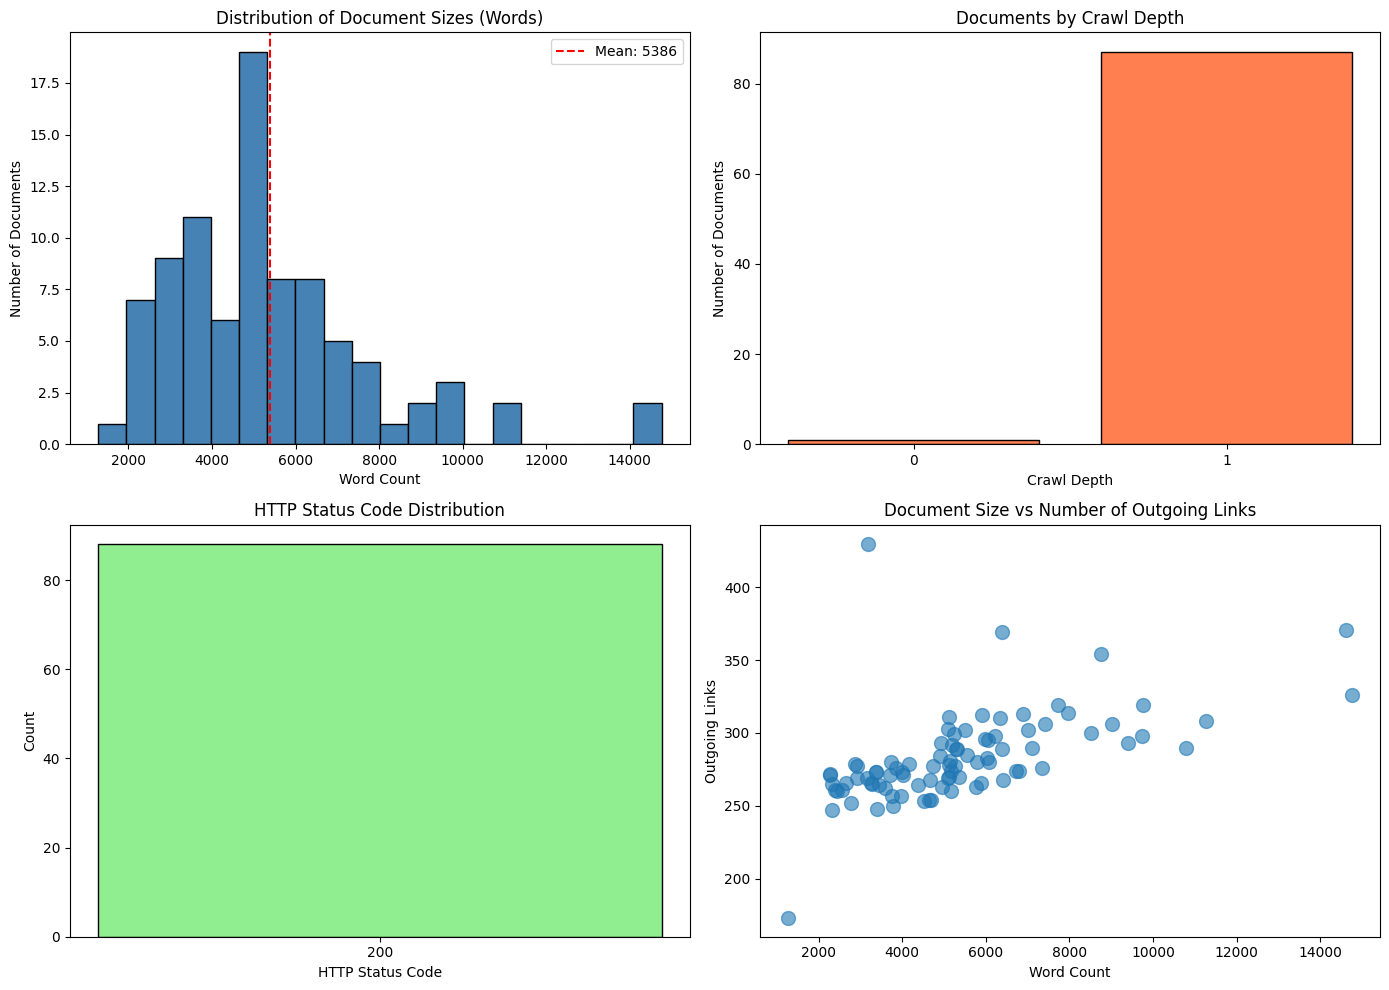

✓ Visualizations complete


In [4]:
# Word count distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Word count histogram
axes[0, 0].hist(df_raw['Words'], bins=20, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Documents')
axes[0, 0].set_title('Distribution of Document Sizes (Words)')
axes[0, 0].axvline(df_raw['Words'].mean(), color='red', linestyle='--', label=f'Mean: {df_raw["Words"].mean():.0f}')
axes[0, 0].legend()

# 2. Depth distribution
depth_counts = df_raw['Depth'].value_counts().sort_index()
axes[0, 1].bar(depth_counts.index, depth_counts.values, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Crawl Depth')
axes[0, 1].set_ylabel('Number of Documents')
axes[0, 1].set_title('Documents by Crawl Depth')
axes[0, 1].set_xticks(range(int(df_raw['Depth'].min()), int(df_raw['Depth'].max()) + 1))

# 3. Status codes
status_counts = df_raw['Status'].value_counts()
axes[1, 0].bar(status_counts.index.astype(str), status_counts.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('HTTP Status Code')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('HTTP Status Code Distribution')

# 4. Links per document
axes[1, 1].scatter(df_raw['Words'], df_raw['Links'], alpha=0.6, s=100)
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Outgoing Links')
axes[1, 1].set_title('Document Size vs Number of Outgoing Links')

plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

## 4. View Top Documents by Size

In [5]:
print("=== TOP 5 LARGEST DOCUMENTS ===")
top_docs = df_raw.nlargest(5, 'Words')[['Title', 'Words', 'URL', 'Depth']]
display(top_docs)

print("\n=== SMALLEST DOCUMENTS ===")
small_docs = df_raw.nsmallest(5, 'Words')[['Title', 'Words', 'URL', 'Depth']]
display(small_docs)

=== TOP 5 LARGEST DOCUMENTS ===


,Title,Words,URL,Depth
13,Backend services overview | Cloud Load Balan...,14759,https://docs.cloud.google.com/load-balancing/d...,1
25,External Application Load Balancer overview |...,14626,https://docs.cloud.google.com/load-balancing/d...,1
38,Global external Application Load Balancer logg...,11267,https://docs.cloud.google.com/load-balancing/d...,1
44,Request distribution for external Application ...,10780,https://docs.cloud.google.com/load-balancing/d...,1
62,Set up regional external Application Load Bala...,9768,https://docs.cloud.google.com/load-balancing/d...,1



=== SMALLEST DOCUMENTS ===


,Title,Words,URL,Depth
3,API and gcloud CLI references | Cloud Load B...,1278,https://docs.cloud.google.com/load-balancing/d...,1
39,External Application Load Balancer logging and...,2268,https://docs.cloud.google.com/load-balancing/d...,1
1,Roles and permissions | Cloud Load Balancing...,2277,https://docs.cloud.google.com/load-balancing/d...,1
65,Set up a URL redirect for a classic Applicatio...,2315,https://docs.cloud.google.com/load-balancing/d...,1
81,Internal passthrough Network Load Balancer and...,2315,https://docs.cloud.google.com/load-balancing/d...,1


## 5. Inspect Individual Document Content

In [6]:
# Pick a medium-sized document to inspect
sample_idx = len(raw_docs) // 2
sample_doc = raw_docs[sample_idx]

print(f"=== SAMPLE DOCUMENT INSPECTION ===")
print(f"URL: {sample_doc.get('url', 'N/A')}")
print(f"Title: {sample_doc.get('title', 'N/A')}")
print(f"Word Count: {sample_doc.get('word_count', 0)}")
print(f"Crawl Depth: {sample_doc.get('crawl_depth', 0)}")
print(f"Status Code: {sample_doc.get('status_code', 'N/A')}")
print(f"Outgoing Links: {len(sample_doc.get('outgoing_links', []))}")

# Show first 500 characters of content
content_preview = sample_doc.get('markdown_content', '')[:500]
print(f"\n=== CONTENT PREVIEW (first 500 chars) ===")
print(content_preview)
print("...")

=== SAMPLE DOCUMENT INSPECTION ===
URL: https://docs.cloud.google.com/load-balancing/docs/https/request-distribution
Title: Request distribution for external Application Load Balancers  |  Cloud Load Balancing  |  Google Cloud Documentation
Word Count: 10780
Crawl Depth: 1
Status Code: 200
Outgoing Links: 290

=== CONTENT PREVIEW (first 500 chars) ===
[ Skip to main content ](https://docs.cloud.google.com/load-balancing/docs/https/request-distribution#main-content)
[ ![Google Cloud Documentation](https://www.gstatic.com/devrel-devsite/prod/v6ae673272608590539f8a06b3f3271c0f5688cde07499d1c9e644aeb66c8c060/clouddocs/images/lockup.svg) ](https://docs.cloud.google.com/)
[ Technology areas ](https://docs.cloud.google.com/docs)
close
  * [ AI and ML  ](https://docs.cloud.google.com/docs/ai-ml)
  * [ Application development  ](https://docs.cloud.goo
...


## 6. Load Processed Documents (if available)

In [7]:
# Load processed documents
processed_json_files = list(PROCESSED_DOCS_DIR.glob("*.json"))
processed_docs = []

for json_file in processed_json_files:
    if json_file.name in ["processing_reports.json", "crawl_summary.json"]:
        continue
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            doc = json.load(f)
            processed_docs.append(doc)
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"✓ Loaded {len(processed_docs)} processed documents")

# Load processing reports
reports_file = PROCESSED_DOCS_DIR / "processing_reports.json"
if reports_file.exists():
    with open(reports_file, 'r', encoding='utf-8') as f:
        reports = json.load(f)
    
    print(f"\n=== PROCESSING SUMMARY ===")
    print(f"Total input: {reports.get('processing_log', {}).get('total_input', 'N/A')}")
    print(f"Cleaned: {reports.get('processing_log', {}).get('cleaned', 'N/A')}")
    print(f"Deduplicated: {reports.get('processing_log', {}).get('deduplicated', 'N/A')}")
    print(f"Validated & Kept: {reports.get('processing_log', {}).get('validated', 'N/A')}")
    print(f"Failed/Discarded: {reports.get('processing_log', {}).get('failed', 'N/A')}")
else:
    print("✗ Processing reports not found (likely not processed yet)")

✓ Loaded 88 processed documents

=== PROCESSING SUMMARY ===
Total input: 89
Cleaned: 89
Deduplicated: 0
Validated & Kept: 88
Failed/Discarded: 1


## 7. Compare Raw vs Processed (Before/After)

In [8]:
if processed_docs:
    # Create comparison
    df_processed = pd.DataFrame([
        {
            'URL': doc.get('url', 'N/A'),
            'Title': doc.get('title', 'N/A'),
            'Words': doc.get('word_count', 0),
        }
        for doc in processed_docs
    ])
    
    print(f"\n=== BEFORE vs AFTER ===")
    print(f"Raw documents: {len(raw_docs)}")
    print(f"Processed documents: {len(processed_docs)}")
    print(f"Removed: {len(raw_docs) - len(processed_docs)}")
    print(f"\nWord count reduction:")
    print(f"  Raw total words: {df_raw['Words'].sum():,}")
    print(f"  Processed total words: {df_processed['Words'].sum():,}")
    print(f"  Reduction: {(1 - df_processed['Words'].sum() / df_raw['Words'].sum()) * 100:.1f}%")
else:
    print("✗ No processed documents found yet")


=== BEFORE vs AFTER ===
Raw documents: 88
Processed documents: 88
Removed: 0

Word count reduction:
  Raw total words: 473,986
  Processed total words: 473,986
  Reduction: 0.0%


## 8. Quality Checks

In [9]:
print("=== DATA QUALITY CHECKS ===")

# Check 1: All documents have required fields
required_fields = ['url', 'title', 'markdown_content', 'word_count', 'crawl_depth', 'status_code']
missing_fields = {}

for field in required_fields:
    count_missing = sum(1 for doc in raw_docs if field not in doc or doc[field] is None)
    if count_missing > 0:
        missing_fields[field] = count_missing

if missing_fields:
    print(f"✗ Missing fields detected:")
    for field, count in missing_fields.items():
        print(f"  - {field}: {count} documents")
else:
    print(f"✓ All documents have required fields")

# Check 2: Content quality
empty_content = sum(1 for doc in raw_docs if not doc.get('markdown_content', '').strip())
print(f"✓ Empty content: {empty_content} documents")

# Check 3: URLs
invalid_urls = sum(1 for doc in raw_docs if not doc.get('url', '').startswith('http'))
print(f"✓ Invalid URLs: {invalid_urls} documents")

# Check 4: Word count validation
print(f"\n✓ Word count range: {df_raw['Words'].min()} - {df_raw['Words'].max()}")
print(f"✓ Docs under 100 words: {len(df_raw[df_raw['Words'] < 100])}")
print(f"✓ Docs over 15000 words: {len(df_raw[df_raw['Words'] > 15000])}")

=== DATA QUALITY CHECKS ===
✓ All documents have required fields
✓ Empty content: 0 documents
✓ Invalid URLs: 0 documents

✓ Word count range: 1278 - 14759
✓ Docs under 100 words: 0
✓ Docs over 15000 words: 0


## 9. Next Steps

Based on this inspection, the next steps are:

1. **If crawl looks good**: Proceed to Phase 2 (Chunking)
2. **If issues detected**: Review and adjust crawler/filter configuration
3. **Manual inspection**: Pick a few documents and read the full content to verify quality

### Summary
- ✓ Crawled {len(raw_docs)} documents from GCP Load Balancing docs
- ✓ Total content: {df_raw['Words'].sum():,} words
- ✓ Documents span crawl depths 0-{int(df_raw['Depth'].max())}
- → Ready for processing: [Run `python main.py` from project root]